<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/Unit_06/HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import

In [105]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", palette="magma")

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [80]:
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

stop_words = set(stopwords.words("english"))
stemmer = SnowballStemmer("english")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Kaggle Setup

In [2]:
import os
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [3]:
# in case of error, rerun the cell, sometimes creds from the previoues cell take more time to load
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.set_config_value("username", userdata.get("KAGGLE_USERNAME"), quiet=True)
api.set_config_value("key", userdata.get("KAGGLE_API_TOKEN"), quiet=True)

In [14]:
import glob

def load_competition_data(competition):
    files = api.competition_list_files(competition).files
    for file in files:
        print(file.name)

    return {
        f.name[:-4]: (
            api.competition_download_file(competition, f.name, path='.'),
            pd.read_csv(glob.glob(f.name + '*')[0])
        )[1]
        for f in files if f.name.endswith('.csv')
    }

In [26]:
competition = 'tweet-sentiment-extraction'

dfs = load_competition_data(competition)

raw_train_df = dfs["train"].set_index('textID')
raw_test_df = dfs["test"].set_index('textID')
raw_sample_submission = dfs["sample_submission"]

sample_submission.csv
test.csv
train.csv
sample_submission.csv: Skipping, found more recently modified local copy (use --force to force download)
test.csv: Skipping, found more recently modified local copy (use --force to force download)
train.csv.zip: Skipping, found more recently modified local copy (use --force to force download)


# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [27]:
raw_train_df.head(5)

,text,selected_text,sentiment
textID,,,
cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
088c60f138,my boss is bullying me...,bullying me,negative
9642c003ef,what interview! leave me alone,leave me alone,negative
358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [28]:
raw_train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27481 entries, cb774db0d1 to 6f7127d9d7
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           27480 non-null  object
 1   selected_text  27480 non-null  object
 2   sentiment      27481 non-null  object
dtypes: object(3)
memory usage: 858.8+ KB


In [29]:
print(f"Кількість записів: {raw_train_df.shape[0]}")
print(f"Кількість колонок: {raw_train_df.shape[1]}")

Кількість записів: 27481
Кількість колонок: 3


In [30]:
raw_train_df.isnull().sum()

,0
text,1
selected_text,1
sentiment,0


In [31]:
raw_train_df.describe()

,text,selected_text,sentiment
count,27480,27480,27481
unique,27480,22463,3
top,All this flirting going on - The ATG smiles...,good,neutral
freq,1,199,11118


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [33]:
# Кількість класів та розподіл міток
class_counts = raw_train_df["sentiment"].value_counts()
class_pct = raw_train_df["sentiment"].value_counts(normalize=True).mul(100).round(2)

dist = pd.DataFrame({"count": class_counts, "percent": class_pct})
print(f"Кількість класів: {raw_train_df['sentiment'].nunique()}")
display(dist)

Кількість класів: 3


,count,percent
sentiment,,
neutral,11118,40.46
positive,8582,31.23
negative,7781,28.31


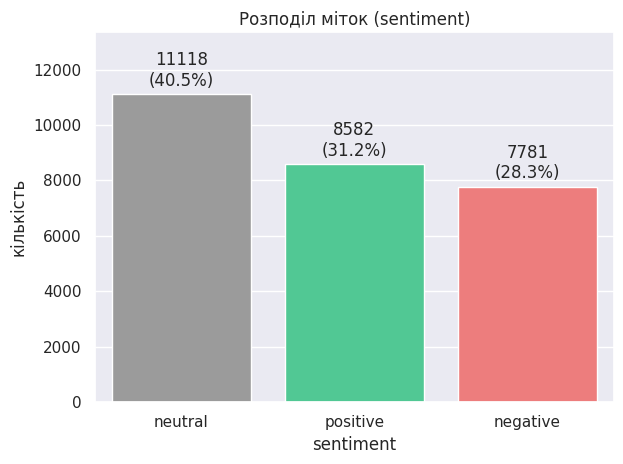

In [53]:
order = class_counts.index
palette = {
    "positive": "#3ddc97",
    "neutral":  "#9b9b9b",
    "negative": "#ff6b6b",
}

ax = sns.countplot(
    data=raw_train_df,
    x="sentiment",
    order=order,
    palette=palette,
    hue="sentiment",
    legend=False,
)
ax.set_title("Розподіл міток (sentiment)")
ax.set_xlabel("sentiment")
ax.set_ylabel("кількість")

total = len(raw_train_df["sentiment"].dropna())
for container in ax.containers:
    labels = [f"{int(p.get_height())}\n({p.get_height() / total * 100:.1f}%)"
              for p in container]
    ax.bar_label(container, labels=labels, padding=3)

ax.margins(y=0.20)
plt.tight_layout()
plt.show()

In [57]:
# довжина без рядка з NaN
df_len = raw_train_df.dropna(subset=["text"]).copy()
df_len["text_len"] = df_len["text"].str.len()

print(df_len["text_len"].describe().round(2))

count    27480.00
mean        68.33
std         35.60
min          3.00
25%         39.00
50%         64.00
75%         97.00
max        141.00
Name: text_len, dtype: float64


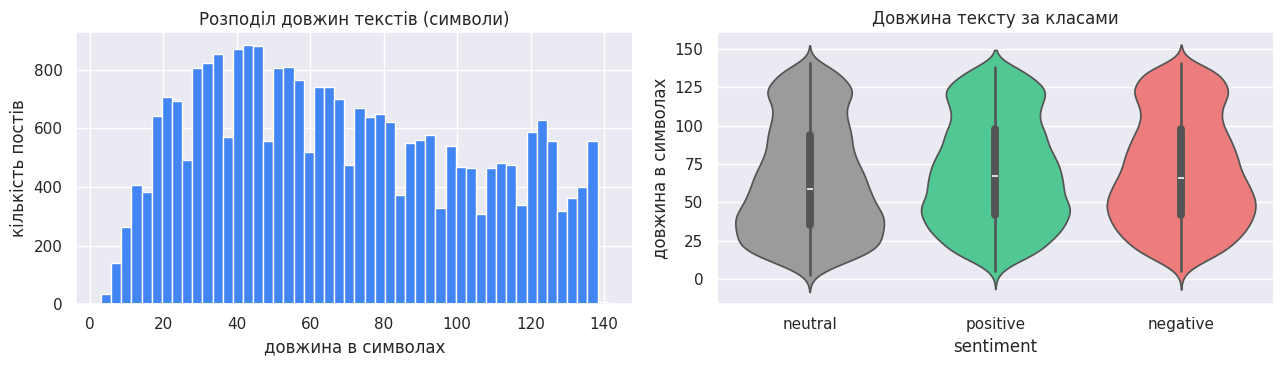

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(
    df_len["text_len"],
    bins=50,
    color="#4285f4",
    edgecolor="white",
)
axes[0].set_title("Розподіл довжин текстів (символи)")
axes[0].set_xlabel("довжина в символах")
axes[0].set_ylabel("кількість постів")


sns.violinplot(
    data=df_len,
    x="sentiment",
    y="text_len",
    order=class_counts.index,
    hue="sentiment",
    palette=palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Довжина тексту за класами")
axes[1].set_xlabel("sentiment")
axes[1].set_ylabel("довжина в символах")

plt.suptitle("")
plt.tight_layout()
plt.show()

**Висновок:**

* Класи помірно незбалансовані: neutral 40.5%, positive 31.2%, negative 28.3%, треба використати stratify при спліті
* Довжини текстів: медіана 64 символи, максимум 141 (ліміт Twitter старого формату). Розподіл правоскошений.
* За класами розподіли довжин схожі, довжина як ознака не виглядає сильною.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [78]:
# help(CountVectorizer)

In [60]:
# helpers
def clean(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+|@\w+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text

def tokenize_and_stem(text):
    tokens = word_tokenize(text)
    return [
        stemmer.stem(t)
        for t in tokens
        if t not in stop_words and len(t) > 1
    ]

In [62]:
df_bow = raw_train_df.dropna(subset=["text"]).copy()
df_bow.head()

,text,selected_text,sentiment,text_len
textID,,,,
cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,36.0
549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,46.0
088c60f138,my boss is bullying me...,bullying me,negative,25.0
9642c003ef,what interview! leave me alone,leave me alone,negative,31.0
358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,75.0


In [64]:
# clean -> tokenize -> remove stopwords -> snowball stemming
vectorizer = CountVectorizer(
    preprocessor=clean,
    tokenizer=tokenize_and_stem,
    max_features=5000,
    token_pattern=None,   #  !!
)
vectorizer

CountVectorizer(max_features=5000,
                preprocessor=<function clean at 0x7883be546980>,
                token_pattern=None,
                tokenizer=<function tokenize_and_stem at 0x7883be546a20>)

In [66]:
X2 = vectorizer.fit_transform(df_bow["text"])

In [74]:
print(f"""
Розмір матриці:
{X2.shape}

Приклад слів зі словника:
{vectorizer.get_feature_names_out()[:50]}
...
{vectorizer.get_feature_names_out()[-50:]}
"""
)


Розмір матриці: 
(27480, 5000)
      
Приклад слів зі словника: 
['aaaah' 'aah' 'aaron' 'ab' 'abandon' 'abbi' 'abc' 'abil' 'abit' 'abl'
 'absolut' 'abt' 'abus' 'ac' 'academi' 'accept' 'access' 'accid'
 'accident' 'accomplish' 'accord' 'account' 'acct' 'ace' 'ach' 'achiev'
 'acid' 'ack' 'acquir' 'across' 'act' 'action' 'activ' 'actor' 'actress'
 'actual' 'ad' 'ada' 'adam' 'adapt' 'add' 'addict' 'addit' 'address'
 'adjust' 'admir' 'admit' 'adob' 'adopt' 'ador']
...
['yea' 'yeah' 'yeahh' 'yeahhh' 'year' 'yearbook' 'yeeeeah' 'yeh' 'yell'
 'yellow' 'yep' 'yer' 'yes' 'yess' 'yessir' 'yesss' 'yesterday' 'yet'
 'yew' 'yey' 'yippe' 'yo' 'yoga' 'yogurt' 'york' 'young' 'younger' 'your'
 'youth' 'youtub' 'youu' 'yr' 'yrs' 'yt' 'yu' 'yuck' 'yucki' 'yum' 'yumm'
 'yummi' 'yup' 'zac' 'zach' 'zealand' 'zelda' 'zero' 'zoe' 'zombi' 'zone'
 'zoo']



### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [81]:
data = df_bow.copy()
data

,text,selected_text,sentiment,text_len
textID,,,,
cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,36.0
549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,46.0
088c60f138,my boss is bullying me...,bullying me,negative,25.0
9642c003ef,what interview! leave me alone,leave me alone,negative,31.0
358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,75.0
...,...,...,...,...
4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative,77.0
4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative,122.0
f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive,111.0


In [82]:
# у співвідношенні 80/20 зі стратифікацією за класами
train_idx, test_idx = train_test_split(
    data.index,
    test_size=0.2,
    random_state=42,
    stratify=data["sentiment"],
)

print(f"Train: {len(train_idx)}, Test: {len(test_idx)}")

Train: 21984, Test: 5496


In [90]:
# same as in #3
vectorizer = CountVectorizer(
    preprocessor=clean,
    tokenizer=tokenize_and_stem,
    max_features=5000,
    token_pattern=None,
)

In [91]:
X_train_bow = vectorizer.fit_transform(data.loc[train_idx, "text"])
X_test_bow  = vectorizer.transform(data.loc[test_idx, "text"])

y_train = data.loc[train_idx, "sentiment"]
y_test  = data.loc[test_idx, "sentiment"]

print("X_train_bow:", X_train_bow.shape)
print("X_test_bow: ", X_test_bow.shape)

X_train_bow: (21984, 5000)
X_test_bow:  (5496, 5000)


In [92]:
# декілька моделей
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "LinearSVC":          LinearSVC(random_state=42), # хотіла спробувати, бо бачила у вимогах SVM
}

In [93]:
fitted_models = {}
rows = []
for name, model in models.items():
    model.fit(X_train_bow, y_train)
    pred = model.predict(X_test_bow)
    rows.append({
        "model":       name,
        "accuracy":    accuracy_score(y_test, pred),
        "f1_macro":    f1_score(y_test, pred, average="macro"),
        "f1_weighted": f1_score(y_test, pred, average="weighted"),
    })
    fitted_models[name] = model

In [94]:
scores_df = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
scores_df

,model,accuracy,f1_macro,f1_weighted
0,LogisticRegression,0.691594,0.692821,0.692146
1,LinearSVC,0.667213,0.669303,0.667647
2,DecisionTree,0.642831,0.644374,0.642424


In [95]:
# обираємо модель за f1_macro
best_name  = scores_df.iloc[0]["model"]
best_model = fitted_models[best_name]
y_pred = best_model.predict(X_test_bow)

print(f"Найкраща модель: {best_name}\n")
print(classification_report(y_test, y_pred, digits=3))

Найкраща модель: LogisticRegression

              precision    recall  f1-score   support

    negative      0.703     0.628     0.663      1556
     neutral      0.636     0.721     0.676      2223
    positive      0.769     0.711     0.739      1717

    accuracy                          0.692      5496
   macro avg      0.703     0.687     0.693      5496
weighted avg      0.697     0.692     0.692      5496



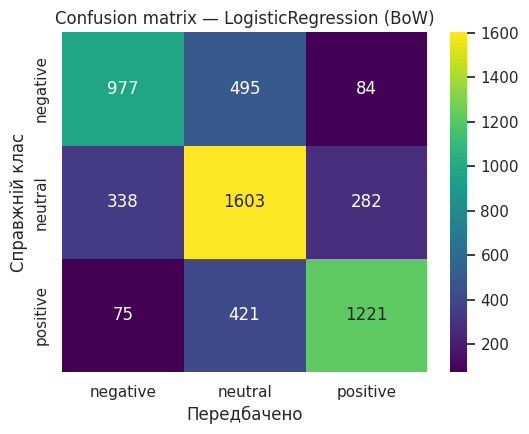

In [99]:
# confusion matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=labels, yticklabels=labels, ax=ax,
)
ax.set_xlabel("Передбачено")
ax.set_ylabel("Справжній клас")
ax.set_title(f"Confusion matrix — {best_name} (BoW)")
plt.tight_layout()
plt.show()

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [103]:
# для кожного класу беремо топ 10 токенів з найбільшим позитивним коефіцієнтом
feature_names = vectorizer.get_feature_names_out()
classes = best_model.classes_
coefs = best_model.coef_

top_n = 10
top_features_bow = {}
for cls_idx, cls in enumerate(classes):
    cls_coefs = coefs[cls_idx]
    top_pos_idx = np.argsort(cls_coefs)[-top_n:][::-1]
    top_features_bow[cls] = pd.DataFrame({
        "token": feature_names[top_pos_idx],
        "coef":  cls_coefs[top_pos_idx],
    })

for cls in classes:
    print(f"\n=== {cls} топ {top_n} токенів ===")
    print(top_features_bow[cls].to_string(index=False))


=== negative топ 10 токенів ===
   token     coef
     sad 2.676209
    suck 2.525239
   sorri 2.435665
    bore 2.401549
    hate 2.331255
  stupid 2.102277
    fail 2.101479
    miss 2.088028
   worst 2.047811
unfortun 1.972906

=== neutral топ 10 токенів ===
   token     coef
  indoor 1.646181
    chan 1.568690
    oooo 1.292843
otherwis 1.280804
      sp 1.227885
   parvo 1.225780
      dd 1.183623
colorado 1.171442
      eu 1.122656
    moro 1.118542

=== positive топ 10 токенів ===
    token     coef
     cute 2.621656
   awesom 2.615685
    thank 2.423902
     love 2.392957
     glad 2.319004
     amaz 2.273966
    enjoy 2.113512
congratul 2.087795
     nice 2.080175
    excit 2.059004


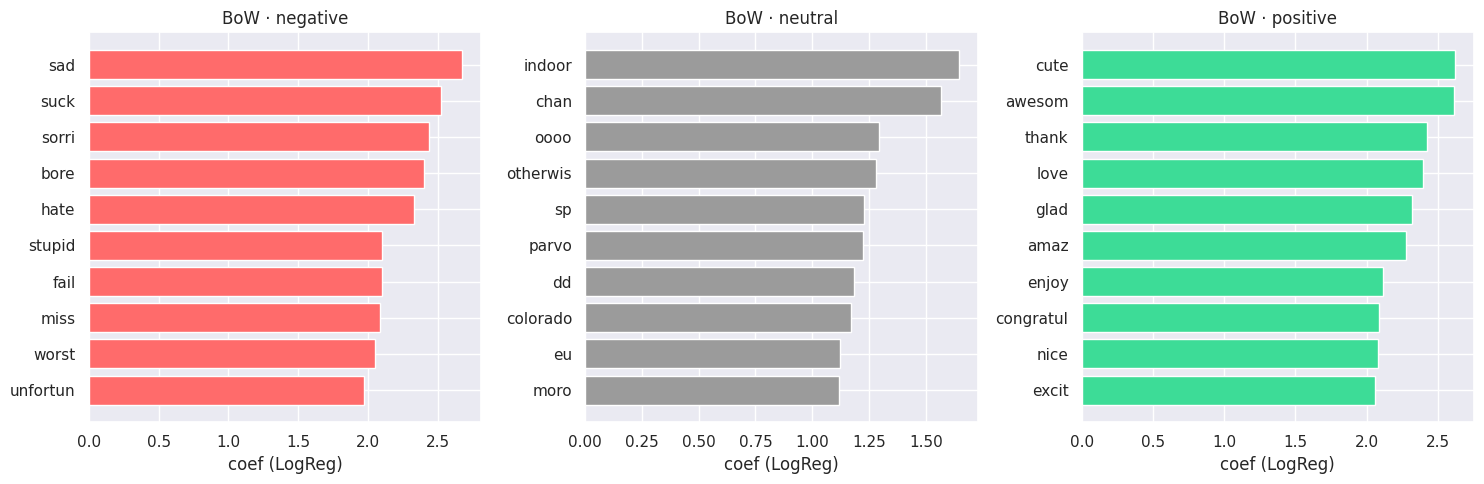

In [104]:
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5), sharex=False)
for ax, cls in zip(axes, classes):
    df_top = top_features_bow[cls].iloc[::-1]
    ax.barh(
        df_top["token"],
        df_top["coef"],
        color=palette.get(cls, "#888888"),
        )
    ax.set_title(f"BoW · {cls}")
    ax.set_xlabel("coef (LogReg)")
plt.tight_layout()
plt.show()

**Висновок:**

* Для `negative` та `positive` топ-токени логічні:
  * sad, hate, miss, suck
  
  vs
  * love, thank, awesom, cute
  
  модель вивчила саме емоційно забарвлені слова.

* Для `neutral` найвпливовіші токени:
  * indoor, chan, parvo, colorado, eu, moro) виглядають як шум: цей клас більше "збиральний", у ньому немає характерної лексики.

* Стеммінг злив форми (`awesome` -> `awesom`, `congratulations` -> `congratul`)

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [106]:
tfidf_vectorizer = TfidfVectorizer(
    preprocessor=clean,
    tokenizer=tokenize_and_stem,
    max_features=5000,
    token_pattern=None,
)

In [107]:
X_train_tfidf = tfidf_vectorizer.fit_transform(data.loc[train_idx, "text"])
X_test_tfidf  = tfidf_vectorizer.transform(data.loc[test_idx, "text"])

print("X_train_tfidf:", X_train_tfidf.shape)
print("X_test_tfidf: ", X_test_tfidf.shape)

X_train_tfidf: (21984, 5000)
X_test_tfidf:  (5496, 5000)


In [108]:
tfidf_model = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
tfidf_model.fit(X_train_tfidf, y_train)
y_pred_tfidf = tfidf_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_tfidf, digits=3))

              precision    recall  f1-score   support

    negative      0.717     0.602     0.654      1556
     neutral      0.623     0.745     0.679      2223
    positive      0.776     0.692     0.732      1717

    accuracy                          0.688      5496
   macro avg      0.705     0.680     0.688      5496
weighted avg      0.697     0.688     0.688      5496



In [109]:
# BoW vs TF-IDF на одній і тій самій моделі та сплітах
compare_df = pd.DataFrame([
    {
        "vectorizer":  "BoW",
        "accuracy":    accuracy_score(y_test, y_pred),
        "f1_macro":    f1_score(y_test, y_pred,    average="macro"),
        "f1_weighted": f1_score(y_test, y_pred,    average="weighted"),
    },
    {
        "vectorizer":  "TF-IDF",
        "accuracy":    accuracy_score(y_test, y_pred_tfidf),
        "f1_macro":    f1_score(y_test, y_pred_tfidf, average="macro"),
        "f1_weighted": f1_score(y_test, y_pred_tfidf, average="weighted"),
    },
])
compare_df

,vectorizer,accuracy,f1_macro,f1_weighted
0,BoW,0.691594,0.692821,0.692146
1,TF-IDF,0.687955,0.688175,0.688293


In [110]:
# топ-токени за коефіцієнтами для TF-IDF моделі
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_coefs = tfidf_model.coef_

top_features_tfidf = {}
for cls_idx, cls in enumerate(tfidf_model.classes_):
    cls_coefs = tfidf_coefs[cls_idx]
    top_pos_idx = np.argsort(cls_coefs)[-top_n:][::-1]
    top_features_tfidf[cls] = pd.DataFrame({
        "token": tfidf_feature_names[top_pos_idx],
        "coef":  cls_coefs[top_pos_idx],
    })

for cls in tfidf_model.classes_:
    print(f"\n=== TF-IDF · {cls} — топ {top_n} токенів ===")
    print(top_features_tfidf[cls].to_string(index=False))


=== TF-IDF · negative — топ 10 токенів ===
 token     coef
   sad 5.259992
  miss 4.807637
 sorri 4.625747
  suck 4.315619
  hate 4.302657
  bore 3.948306
  fail 3.666640
  hurt 3.476230
stupid 3.396024
  poor 3.349017

=== TF-IDF · neutral — топ 10 токенів ===
   token     coef
  indoor 1.302652
  guitar 1.234532
  except 1.105434
    moro 1.102639
      sp 1.027114
   knock 0.978404
   insur 0.966889
    chan 0.959284
  differ 0.951014
otherwis 0.943525

=== TF-IDF · positive — топ 10 токенів ===
 token     coef
  love 6.574601
 thank 5.638891
awesom 4.883312
 great 4.450065
 happi 4.407120
  nice 4.281428
  good 4.238208
  amaz 4.058175
  hope 4.049812
 enjoy 3.912825


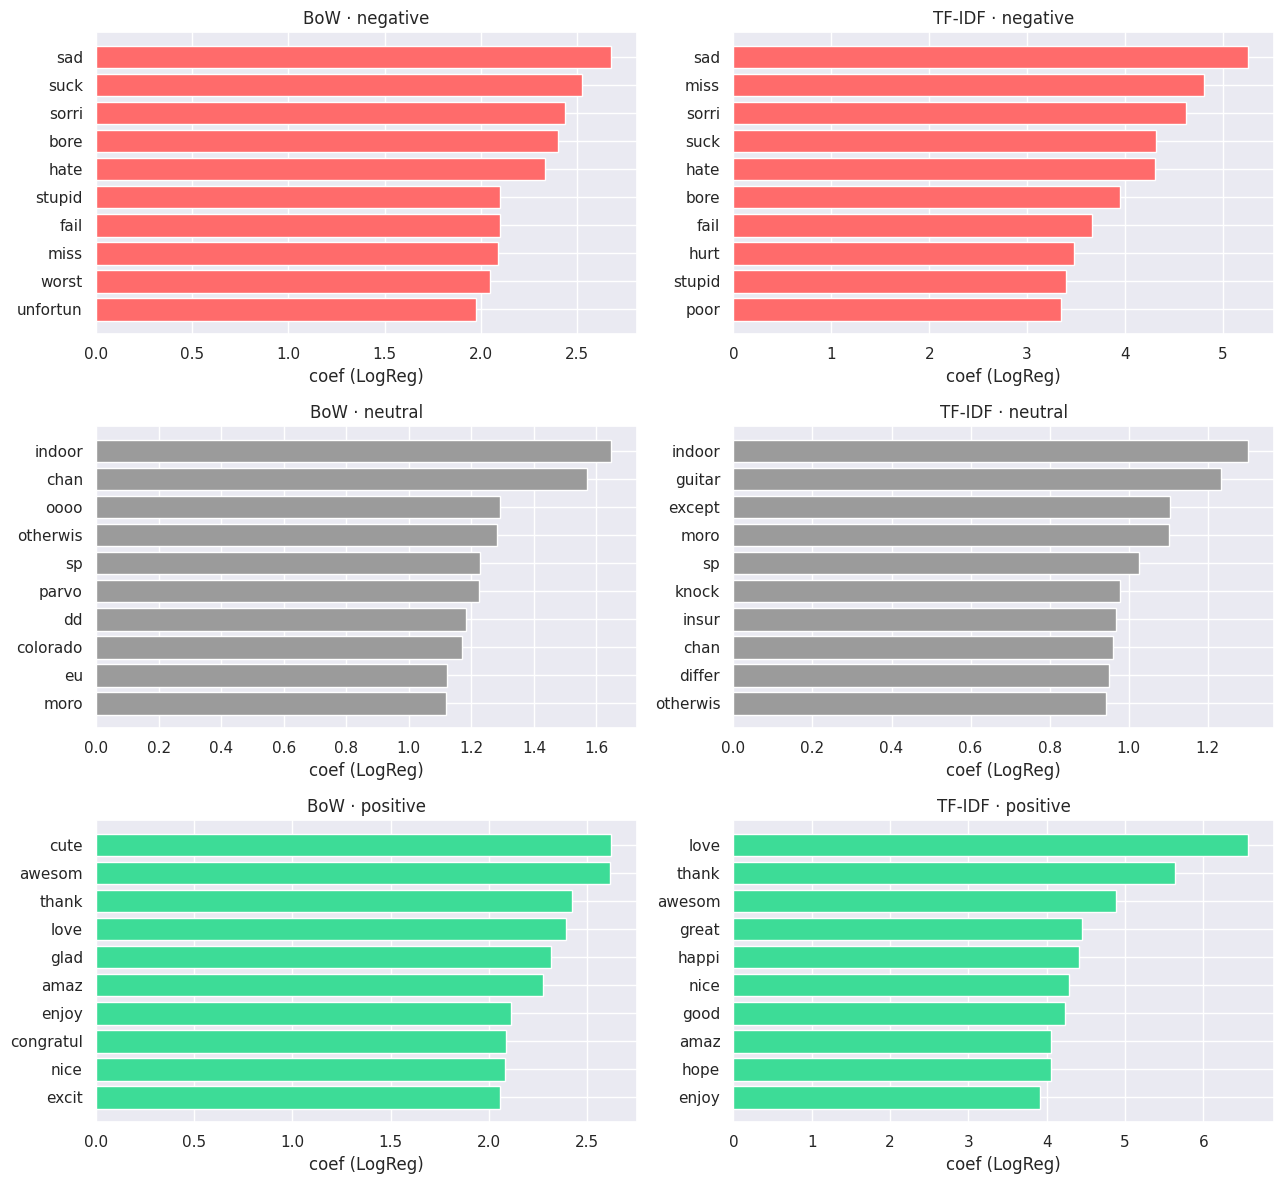

In [111]:
# BoW vs TF-IDF для кожного класу
fig, axes = plt.subplots(len(classes), 2, figsize=(13, 4 * len(classes)))
for row, cls in enumerate(classes):
    for col, (name, src) in enumerate([("BoW", top_features_bow), ("TF-IDF", top_features_tfidf)]):
        df_top = src[cls].iloc[::-1]
        ax = axes[row, col]
        ax.barh(df_top["token"], df_top["coef"], color=palette.get(cls, "#888888"))
        ax.set_title(f"{name} · {cls}")
        ax.set_xlabel("coef (LogReg)")
plt.tight_layout()
plt.show()

**Висновок:**

* Якість майже не змінилася:
BoW дав f1_macro = 0.693, TF-IDF = 0.688.
* Топ-токени для `negative` / `positive` ті самі, але порядок наче кращий. Для `neutral` обидві векторизації дають набір збірної солянки.
* Для фінальної реалізації обрала б **TF-IDF** навіть якщо є просідання в метриці: коефіцієнти інтерпретовніші (рідкісні інформативні слова не губляться серед частих), словник краще масштабується.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [112]:
errors_df = pd.DataFrame({
    "text":      data.loc[test_idx, "text"].values,
    "true":      y_test.values,
    "predicted": y_pred_tfidf,
}, index=test_idx)
errors_df.head()

,text,true,predicted
textID,,,
b8fd4e60d8,Reading and taking notes but undertanding none...,negative,neutral
946f23739a,so sad emma u sad to be leaving the show? ****,negative,negative
605225ad21,Freakin` frustrated why can`t my coach realize...,negative,negative
0abe62c2ee,is feeling so bored... i miss school time,negative,negative
eca513ce47,wow this morning 8.15 hrs ding dong breakfasts...,positive,positive


In [113]:
errors_df = errors_df[errors_df["true"] != errors_df["predicted"]].copy()
errors_df["text_len"] = errors_df["text"].str.len()

print(f"Всього помилок: {len(errors_df)} з {len(test_idx)} ({len(errors_df) / len(test_idx):.1%})")

Всього помилок: 1715 з 5496 (31.2%)


In [115]:
confusion_pairs = (
    errors_df.groupby(["true", "predicted"]).size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

In [116]:
confusion_pairs

,true,predicted,count
0,negative,neutral,540
5,positive,neutral,463
2,neutral,negative,303
3,neutral,positive,263
1,negative,positive,80
4,positive,negative,66


In [118]:
# довжина текстів: помилки vs правильні
correct_lens = data.loc[test_idx, "text"].str.len()[
    ~data.loc[test_idx].index.isin(errors_df.index)
]
print("Довжина (символи) : правильні vs помилкові:")
print(pd.DataFrame({
    "correct": correct_lens.describe(),
    "errors":  errors_df["text_len"].describe(),
}).round(1))

Довжина (символи) : правильні vs помилкові:
       correct  errors
count   3781.0  1715.0
mean      64.5    76.5
std       35.2    34.6
min        3.0     4.0
25%       35.0    48.0
50%       58.0    75.0
75%       91.0   106.0
max      141.0   138.0


In [119]:
pd.set_option("display.max_colwidth", 200)
for (true_cls, pred_cls), group in errors_df.groupby(["true", "predicted"]):
    if true_cls == pred_cls:
        continue
    print(f"\n=== true={true_cls}  ->  pred={pred_cls}   (n={len(group)}) ===")
    sample = group.sample(min(3, len(group)), random_state=42)
    for _, row in sample.iterrows():
        print(f"  • {row['text'].strip()}")


=== true=negative  ->  pred=neutral   (n=540) ===
  • i take it you`re not a fan
  • so wish I was there with ya, but at 6:48am Belgian time I was sleeping...time diff sucks. Take me there!
  • ; Re: Home - that`s exactly what I meant... home in D-town. ;) Also, re: computer... uh... I brokt it...

=== true=negative  ->  pred=positive   (n=80) ===
  • oh, is it good? I`ve been wanting to watch that movie but nooobody would watch it w/me
  • Awww, *hugs* I wish I could help.
  • revision...what fun...still I have thursday to do basically nothing

=== true=neutral  ->  pred=negative   (n=303) ===
  • girl yes, as if having it where you CANT see it wont gross enough
  • I`m having elevated error rates... StreamKeys not found, and then connection problems. Server migration isn`t easy, huh  ?
  • euhm i`m french and i don`t really understand English . poo..

=== true=neutral  ->  pred=positive   (n=263) ===
  • UP was awesome! Everyone should go see it.  But the stupid theatre didn`t show 

**Висновок:**

* Помилок 31.2%. Найчастіше модель плутає інші класи з `neutral` (540 negative -> neutral, 463 positive -> neutral), зсув у бік більшісного класу.
* Помилкові тексти в середньому довші (76.5 vs 64.5 символи), бо ж є складніша структура, більше контексту, який bag-of-words не вловлює дуже гарно.
* Серед прикладів багато сарказму, заперечень та неявних емоцій ("i take it you`re not a fan", "i wish I was there"), їх неможливо класифікувати на рівні окремих слів.

**Шляхи покращення:**
* **Контекстні ембединги (BERT / RoBERTa, fine-tuned на sentiment)** краще справляються з сарказмом, запереченнями та довшими текстами, де bag-of-words програє.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model